In [ ]:
# Run the file CarlaUE4.exe in a background process
import os
import subprocess

command = "CarlaUE4.exe"
# command = "CarlaUE4.exe --quality-level=Low"
#-RenderOffScreen

subprocess.Popen(command, shell=True)

#subprocess.Popen(["CarlaUE4.exe"])

<Popen: returncode: None args: 'CarlaUE4.exe'>

In [ ]:
import carla
import random

# Connect to the client and retrieve the world object
client = carla.Client('localhost', 2000)
world = client.get_world()
world_map = world.get_map()

# Get the blueprint library and filter for the vehicle blueprints
vehicle_blueprints = world.get_blueprint_library().filter('*vehicle*')

# Get the map's spawn points
spawn_points = world_map.get_spawn_points()

# Spawn and mark the ego vehicle
ego_bp = world.get_blueprint_library().find('vehicle.lincoln.mkz_2020')

ego_bp.set_attribute('role_name', 'hero')

ego_vehicle = world.spawn_actor(ego_bp, random.choice(spawn_points))


In [ ]:

# Spawn 50 vehicles randomly distributed throughout the map 
# for each spawn point, we choose a random vehicle from the blueprint library
for i in range(0,250):
    world.try_spawn_actor(random.choice(vehicle_blueprints), random.choice(spawn_points))

# Set autonomous mode for all vehicles (including the ego vehicle)
for vehicle in world.get_actors().filter('vehicle.*'):
    vehicle.set_autopilot(True)


In [ ]:
"""import carla
import random

client = carla.Client('localhost', 2000)
client.set_timeout(10.0)
world = client.get_world()
blueprints = world.get_blueprint_library()

# Number of walkers
num_walkers = 30

# ===========================================================
# 1. Generate spawn points for walkers
# ===========================================================
spawn_points = []
for i in range(num_walkers):
    loc = world.get_random_location_from_navigation()
    if loc:
        spawn_points.append(carla.Transform(loc))

# ===========================================================
# 2. Create walker actors in batch
# ===========================================================
walker_bps = blueprints.filter("walker.pedestrian.*")
walker_spawn_commands = []

for spawn in spawn_points:
    bp = random.choice(walker_bps)

    # Always set 'is_invincible' to false → prevents physics error
    if bp.has_attribute("is_invincible"):
        bp.set_attribute("is_invincible", "false")

    walker_spawn_commands.append(carla.command.SpawnActor(bp, spawn))

# Apply spawn batch
walker_results = client.apply_batch_sync(walker_spawn_commands, True)

# Collect walker actor IDs
walker_ids = [r.actor_id for r in walker_results if not r.error]

# ===========================================================
# 3. Create Controllers for each walker
# ===========================================================
controller_bp = blueprints.find("controller.ai.walker")
controller_spawn_commands = []

for wid in walker_ids:
    controller_spawn_commands.append(
        carla.command.SpawnActor(controller_bp, carla.Transform(), wid)
    )

controller_results = client.apply_batch_sync(controller_spawn_commands, True)

controller_ids = [r.actor_id for r in controller_results if not r.error]

# Get references to actors
walkers = world.get_actors(walker_ids)
controllers = world.get_actors(controller_ids)

# ===========================================================
# 4. Start movement safely
# ===========================================================
for controller in controllers:
    controller.start()
    controller.go_to_location(world.get_random_location_from_navigation())
    controller.set_max_speed(1.4 + random.random())  # 1.4–2.4 m/s"""

'import carla\nimport random\n\nclient = carla.Client(\'localhost\', 2000)\nclient.set_timeout(10.0)\nworld = client.get_world()\nblueprints = world.get_blueprint_library()\n\n# Number of walkers\nnum_walkers = 30\n\n# ===========================================================\n# 1. Generate spawn points for walkers\n# ===========================================================\nspawn_points = []\nfor i in range(num_walkers):\n    loc = world.get_random_location_from_navigation()\n    if loc:\n        spawn_points.append(carla.Transform(loc))\n\n# ===========================================================\n# 2. Create walker actors in batch\n# ===========================================================\nwalker_bps = blueprints.filter("walker.pedestrian.*")\nwalker_spawn_commands = []\n\nfor spawn in spawn_points:\n    bp = random.choice(walker_bps)\n\n    # Always set \'is_invincible\' to false → prevents physics error\n    if bp.has_attribute("is_invincible"):\n        bp.set_attrib

In [ ]:
from MIREIA.simulation.bridge import SimulationBridge
bridge = SimulationBridge(world)

print(bridge.ego)
print(bridge.dynamic_obstacles)
print(bridge.env_state)
print(bridge)
bridge.update()
print(bridge.waypoints.get_closest_waypoint(bridge.ego.x, bridge.ego.y))

print(len(bridge.get_static_obstacles()))

ID: 24, ActorKinematics(x=-41.83, y=-16.56, v=0.00, vx=0.00, vy=0.00, heading=-90.2)
[ID: 25, ActorKinematics(x=-41.75, y=-41.37, v=0.00, vx=0.00, vy=0.00, heading=-89.6), ID: 26, ActorKinematics(x=-113.40, y=-25.77, v=0.00, vx=0.00, vy=0.00, heading=90.6), ID: 27, ActorKinematics(x=-78.03, y=12.97, v=0.00, vx=0.00, vy=0.00, heading=-179.8), ID: 28, ActorKinematics(x=106.03, y=67.42, v=0.00, vx=0.00, vy=0.00, heading=-89.6), ID: 29, ActorKinematics(x=109.52, y=89.84, v=0.00, vx=0.00, vy=0.00, heading=-89.6), ID: 30, ActorKinematics(x=-27.02, y=69.72, v=0.00, vx=0.00, vy=0.00, heading=0.1), ID: 31, ActorKinematics(x=-64.10, y=16.51, v=0.00, vx=0.00, vy=0.00, heading=-179.8), ID: 32, ActorKinematics(x=-103.18, y=-14.43, v=0.00, vx=0.00, vy=0.00, heading=-89.4), ID: 33, ActorKinematics(x=99.38, y=-6.31, v=0.00, vx=0.00, vy=0.00, heading=90.4), ID: 34, ActorKinematics(x=57.57, y=-67.85, v=0.00, vx=0.00, vy=0.00, heading=180.0), ID: 35, ActorKinematics(x=10.91, y=-57.40, v=0.00, vx=0.00, vy

In [ ]:
from MIREIA.simulation.sensors import SensorManager
sensors = SensorManager(world, world_map, ego_vehicle, save_dir="output", map_resolution=(3000, 3000))
sensors.clean_output_directory()

In [ ]:
sensors.save_ego_frame()
sensors.save_map_frame()


In [ ]:
from MIREIA.core.physics import RiskOracle
from MIREIA.analysis.plotter import draw_risk_heatmap_3d
from MIREIA.analysis.plotter import Grid


oracle = RiskOracle()



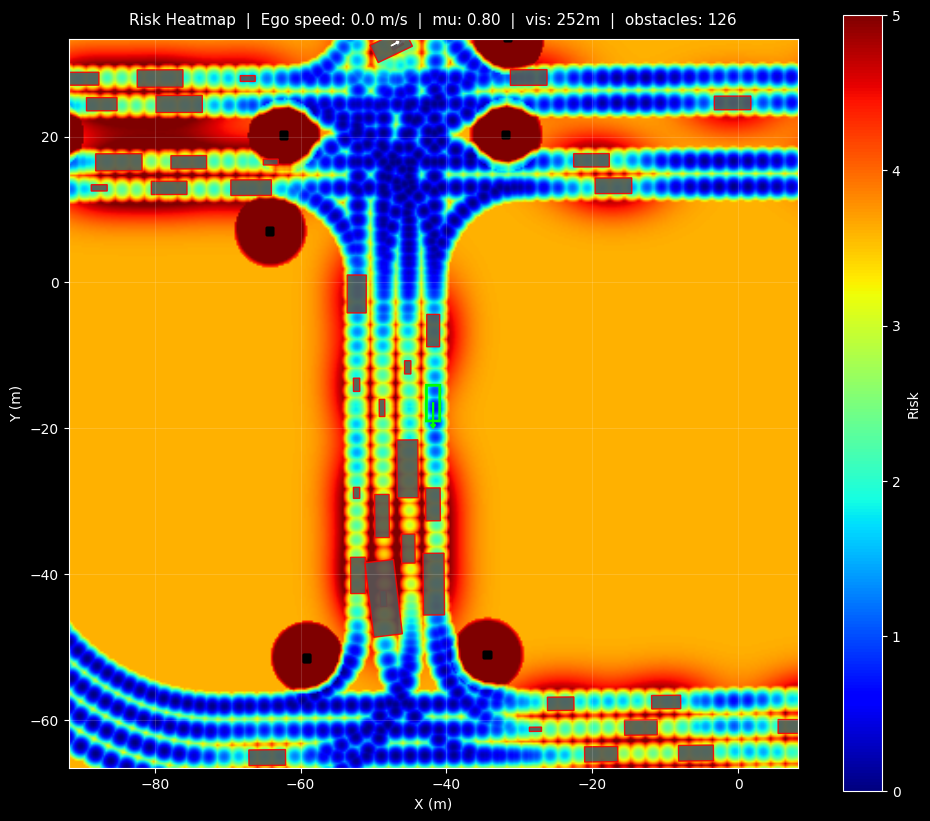

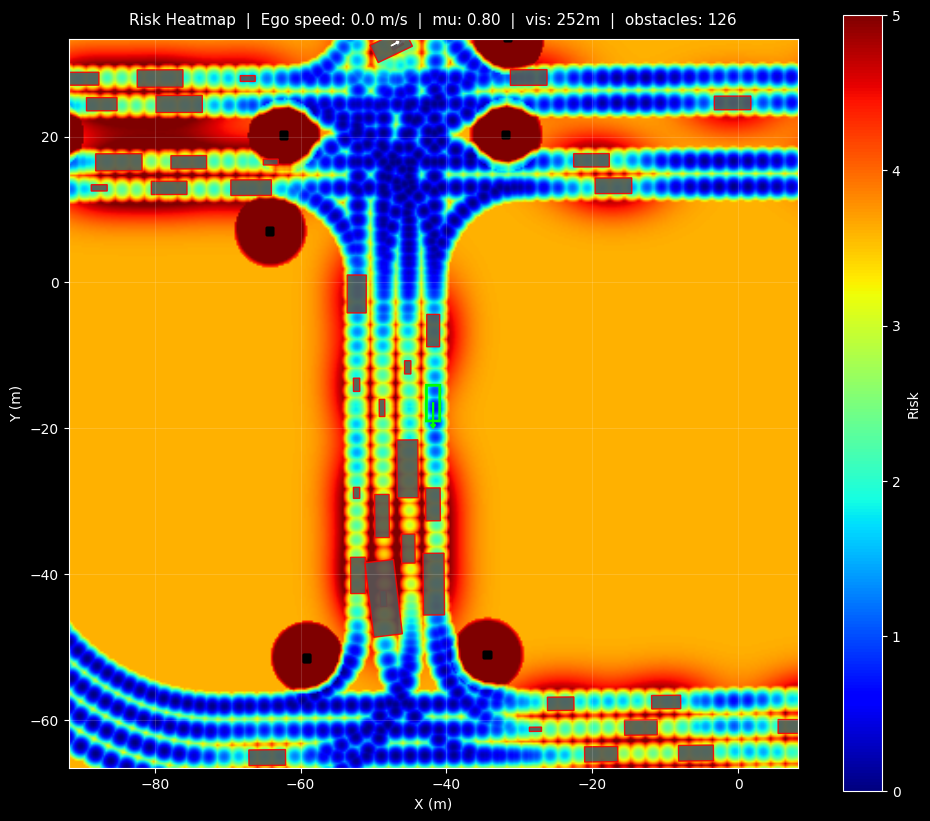

In [ ]:
from MIREIA.analysis.visualizer import RiskGridVisualizer
bridge.update()

ego_x, ego_y = bridge.get_ego_kinematics().x, bridge.get_ego_kinematics().y

grid = Grid(center_x=ego_x, center_y=ego_y, size=100.0, resolution=0.25)
risk_grid = oracle.calculate_risk_map(grid, bridge)

viz = RiskGridVisualizer(risk_grid, bridge, vmax=5.0)
viz.render(save_path="output/risk_heatmap.png")  # or just viz.render() to display inline

In [ ]:
import time
for i in range (1000):
    # Calculate the risk at the exact point of the ego vehicle
    bridge.update()  # Only update dynamic obstacles and ego state
    ego_kinematics = bridge.get_ego_kinematics()
    risk = oracle.calculate_scene_risk((ego_kinematics.x, ego_kinematics.y), bridge)
    print(f"Scene Risk at Ego Position: {risk:.4f}")
    #time.sleep(0.1)  # Simulate time delay between updates

Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Position: 0.7781
Scene Risk at Ego Po

In [ ]:
viz.render_video("output/risk_video.mp4", n_frames=100, grid_size=200.0, grid_resolution=1.0, fps=4)

Frame 100/100
Video saved to output/risk_video.mp4


In [ ]:
sensors.save_ego_frames()

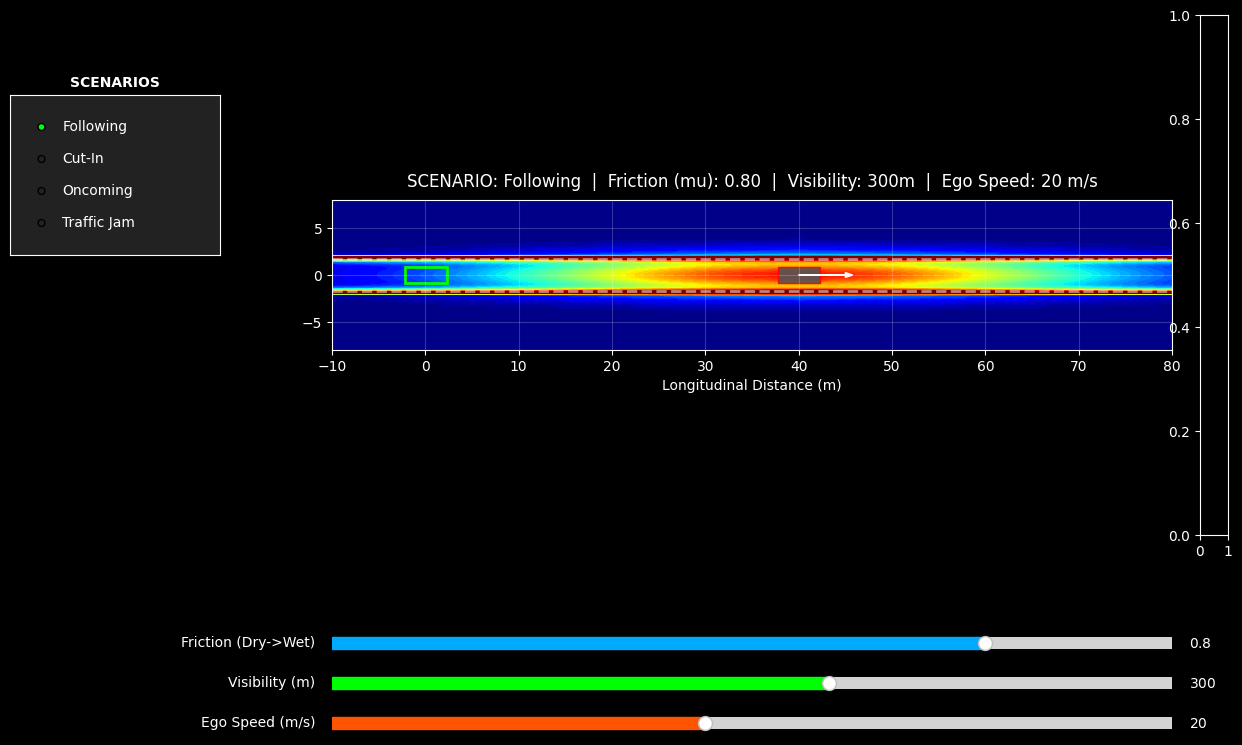

In [ ]:
from MIREIA.analysis.visualizer import DummyRiskVisualizer
visualizer = DummyRiskVisualizer()

In [ ]:
settings = world.get_settings()
settings.synchronous_mode = True # Enables synchronous mode
settings.fixed_delta_seconds = 0.05
world.apply_settings(settings)

# If synchronous mode is enabled, and there is a Traffic Manager running, this must be set to sync mode too. 

In [ ]:
client.get_available_maps()

['Town01',
 'Town01_Opt',
 'Town02',
 'Town02_Opt',
 'Town03',
 'Town03_Opt',
 'Town04',
 'Town04_Opt',
 'Town05',
 'Town05_Opt',
 'Town10HD',
 'Town10HD_Opt',
 'AnnotationColorLandscape']

In [ ]:
client.load_world('Town05')

In [ ]:
# Retrieve the spectator object
spectator = world.get_spectator()

# Get the location and rotation of the spectator through its transform
transform = spectator.get_transform()

location = transform.location
rotation = transform.rotation

# Set the spectator with an empty transform
spectator.set_transform(carla.Transform())
# This will set the spectator at the origin of the map, with 0 degrees
# pitch, yaw and roll - a good way to orient yourself in the map

In [ ]:
# Create a transform to place the camera on top of the vehicle
camera_init_trans = carla.Transform(carla.Location(z=1.5))

# We create the camera through a blueprint that defines its properties
camera_bp = world.get_blueprint_library().find('sensor.camera.rgb')

# We spawn the camera and attach it to our ego vehicle
camera = world.spawn_actor(camera_bp, camera_init_trans, attach_to=ego_vehicle)

NameError: name 'ego_vehicle' is not defined

In [ ]:
# Start camera with PyGame callback
camera.listen(lambda image: image.save_to_disk('out/%06d.png' % image.frame))

NameError: name 'camera' is not defined

In [ ]:
for vehicle in world.get_actors().filter('*vehicle*'):
    vehicle.set_autopilot(True)

Recording

Parameter	Description	Notes
start	Recording time in seconds to start the simulation at.	If positive, time will be considered from the beginning of the recording. If negative, it will be considered from the end.
duration	Seconds to playback. 0 is all the recording.	By the end of the playback, vehicles will be set to autopilot and pedestrians will stop.
camera	ID of the actor that the camera will focus on.	Set it to 0 to let the spectator move freely.

In [ ]:
client.start_recorder("/home/carla/recording01.log", additional_data = False)

In [ ]:
client.stop_recorder()

In [ ]:
client.replay_file("recording01.log", start, duration, camera)

In [ ]:
# Spawn pedestrians
walker_blueprints = world.get_blueprint_library().filter('*walker.pedestrian*')
spawn_points = world.get_map().get_spawn_points()
num_pedestrians = 20
spawned_pedestrians = []
for i in range(num_pedestrians):
    walker_bp = random.choice(walker_blueprints)
    spawn_point = random.choice(spawn_points)
    pedestrian = world.try_spawn_actor(walker_bp, spawn_point)
    if pedestrian:
        spawned_pedestrians.append(pedestrian)

# Give pedestrians AI controllers and start them walking
walker_controller_bp = world.get_blueprint_library().find('controller.ai.walker')
for pedestrian in spawned_pedestrians:
    controller = world.try_spawn_actor(walker_controller_bp, carla.Transform(), attach_to=pedestrian)
    if controller:
        controller.start()
        controller.go_to_location(world.get_random_location_from_navigation())
        controller.set_max_speed(1 + random.random())  # random speed between 1 and 2 m/s

: 

In [ ]:
import math
import time



# Get all vehicles and pedestrians
vehicles = world.get_actors().filter('*vehicle*')
pedestrians = world.get_actors().filter('*walker.pedestrian*')

# Select a random vehicle
vehicle = random.choice(vehicles)

frame_count = 0
sum_value = 0

while True:
    world.tick()  # Advance simulation by one frame
    frame_count += 1

    # Get vehicle speed (m/s)
    velocity = vehicle.get_velocity()
    speed = math.sqrt(velocity.x**2 + velocity.y**2 + velocity.z**2)

    # Calculate sum for all pedestrians
    sum_value = 0
    vehicle_location = vehicle.get_location()
    for pedestrian in pedestrians:
        pedestrian_location = pedestrian.get_location()
        dx = vehicle_location.x - pedestrian_location.x
        dy = vehicle_location.y - pedestrian_location.y
        dz = vehicle_location.z - pedestrian_location.z
        dist_sq = dx*dx + dy*dy + dz*dz
        if dist_sq > 0:
            sum_value += speed * (1.0 / dist_sq)

    if frame_count % 20 == 0:
        print(f"Frame {frame_count}: Sum = {sum_value}")
    # Optional: add a small sleep to avoid locking up the notebook
    # time.sleep(0.01)

Frame 20: Sum = 0.0052763063830341805
Frame 40: Sum = 0.005570217433621447
Frame 40: Sum = 0.005570217433621447
Frame 60: Sum = 0.005871794550141724
Frame 60: Sum = 0.005871794550141724
Frame 80: Sum = 0.006778233553734924
Frame 80: Sum = 0.006778233553734924
Frame 100: Sum = 0.007134667148302078
Frame 100: Sum = 0.007134667148302078
Frame 120: Sum = 0.0065038443708132065
Frame 120: Sum = 0.0065038443708132065
Frame 140: Sum = 0.0062119684762847885
Frame 140: Sum = 0.0062119684762847885
Frame 160: Sum = 0.00612985062598514
Frame 160: Sum = 0.00612985062598514
Frame 180: Sum = 0.00606589001349112
Frame 180: Sum = 0.00606589001349112
Frame 200: Sum = 0.005904594707259312
Frame 200: Sum = 0.005904594707259312
Frame 220: Sum = 0.007020358620447482
Frame 220: Sum = 0.007020358620447482
Frame 240: Sum = 0.008378028853105943
Frame 240: Sum = 0.008378028853105943
Frame 260: Sum = 0.00649608439005704
Frame 260: Sum = 0.00649608439005704
Frame 280: Sum = 0.004341334348394133
Frame 280: Sum = 0.0

KeyboardInterrupt: 